In [29]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
import stim
import sinter
import matplotlib.pyplot as plt
import os
from qecsim.lattice_surgery.circuit import surgery_circuit
import pickle

In [31]:
#---------------
# Sketches/Notes
#---------------

# 9 12 15
#---------
# 37 43 49
#---------
# M 3 14 27
# TICK
# CX rec[-1] 6 rec[-1] 7 rec[-1] 8 rec[-2] 6 rec[-2] 7 rec[-2] 8 rec[-3] 6 rec[-3] 7 rec[-3] 8
'''
---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
Cell In[167], line 1
----> 1 surgery_circuit(distance = 5, target_state_init = "Z0", control_state_init= "X-")

File <string>:38, in surgery_circuit(distance, target_state_init, control_state_init, noise_depol_data_init, noise_measure_flip)

ValueError: While running backwards through the circuit, during reverse-execution of the instruction
    RX 5 6 7 8 9 24 25 26 27 28 45 46 47 48 49 64 65 66 67 68 85 86 87 88 89 10 11 12 13 14 29 30 31 32 33 50 51 52 53 54 69 70 71 72 73 90 91 92 93 94
the following detecting region vs dissipation anticommutations occurred
    L1 vs stim.target_z(85)
Therefore invalid detectors/observables are present in the circuit.
'''

'\n---------------------------------------------------------------------------\nValueError                                Traceback (most recent call last)\nCell In[167], line 1\n----> 1 surgery_circuit(distance = 5, target_state_init = "Z0", control_state_init= "X-")\n\nFile <string>:38, in surgery_circuit(distance, target_state_init, control_state_init, noise_depol_data_init, noise_measure_flip)\n\nValueError: While running backwards through the circuit, during reverse-execution of the instruction\n    RX 5 6 7 8 9 24 25 26 27 28 45 46 47 48 49 64 65 66 67 68 85 86 87 88 89 10 11 12 13 14 29 30 31 32 33 50 51 52 53 54 69 70 71 72 73 90 91 92 93 94\nthe following detecting region vs dissipation anticommutations occurred\n    L1 vs stim.target_z(85)\nTherefore invalid detectors/observables are present in the circuit.\n'

10j


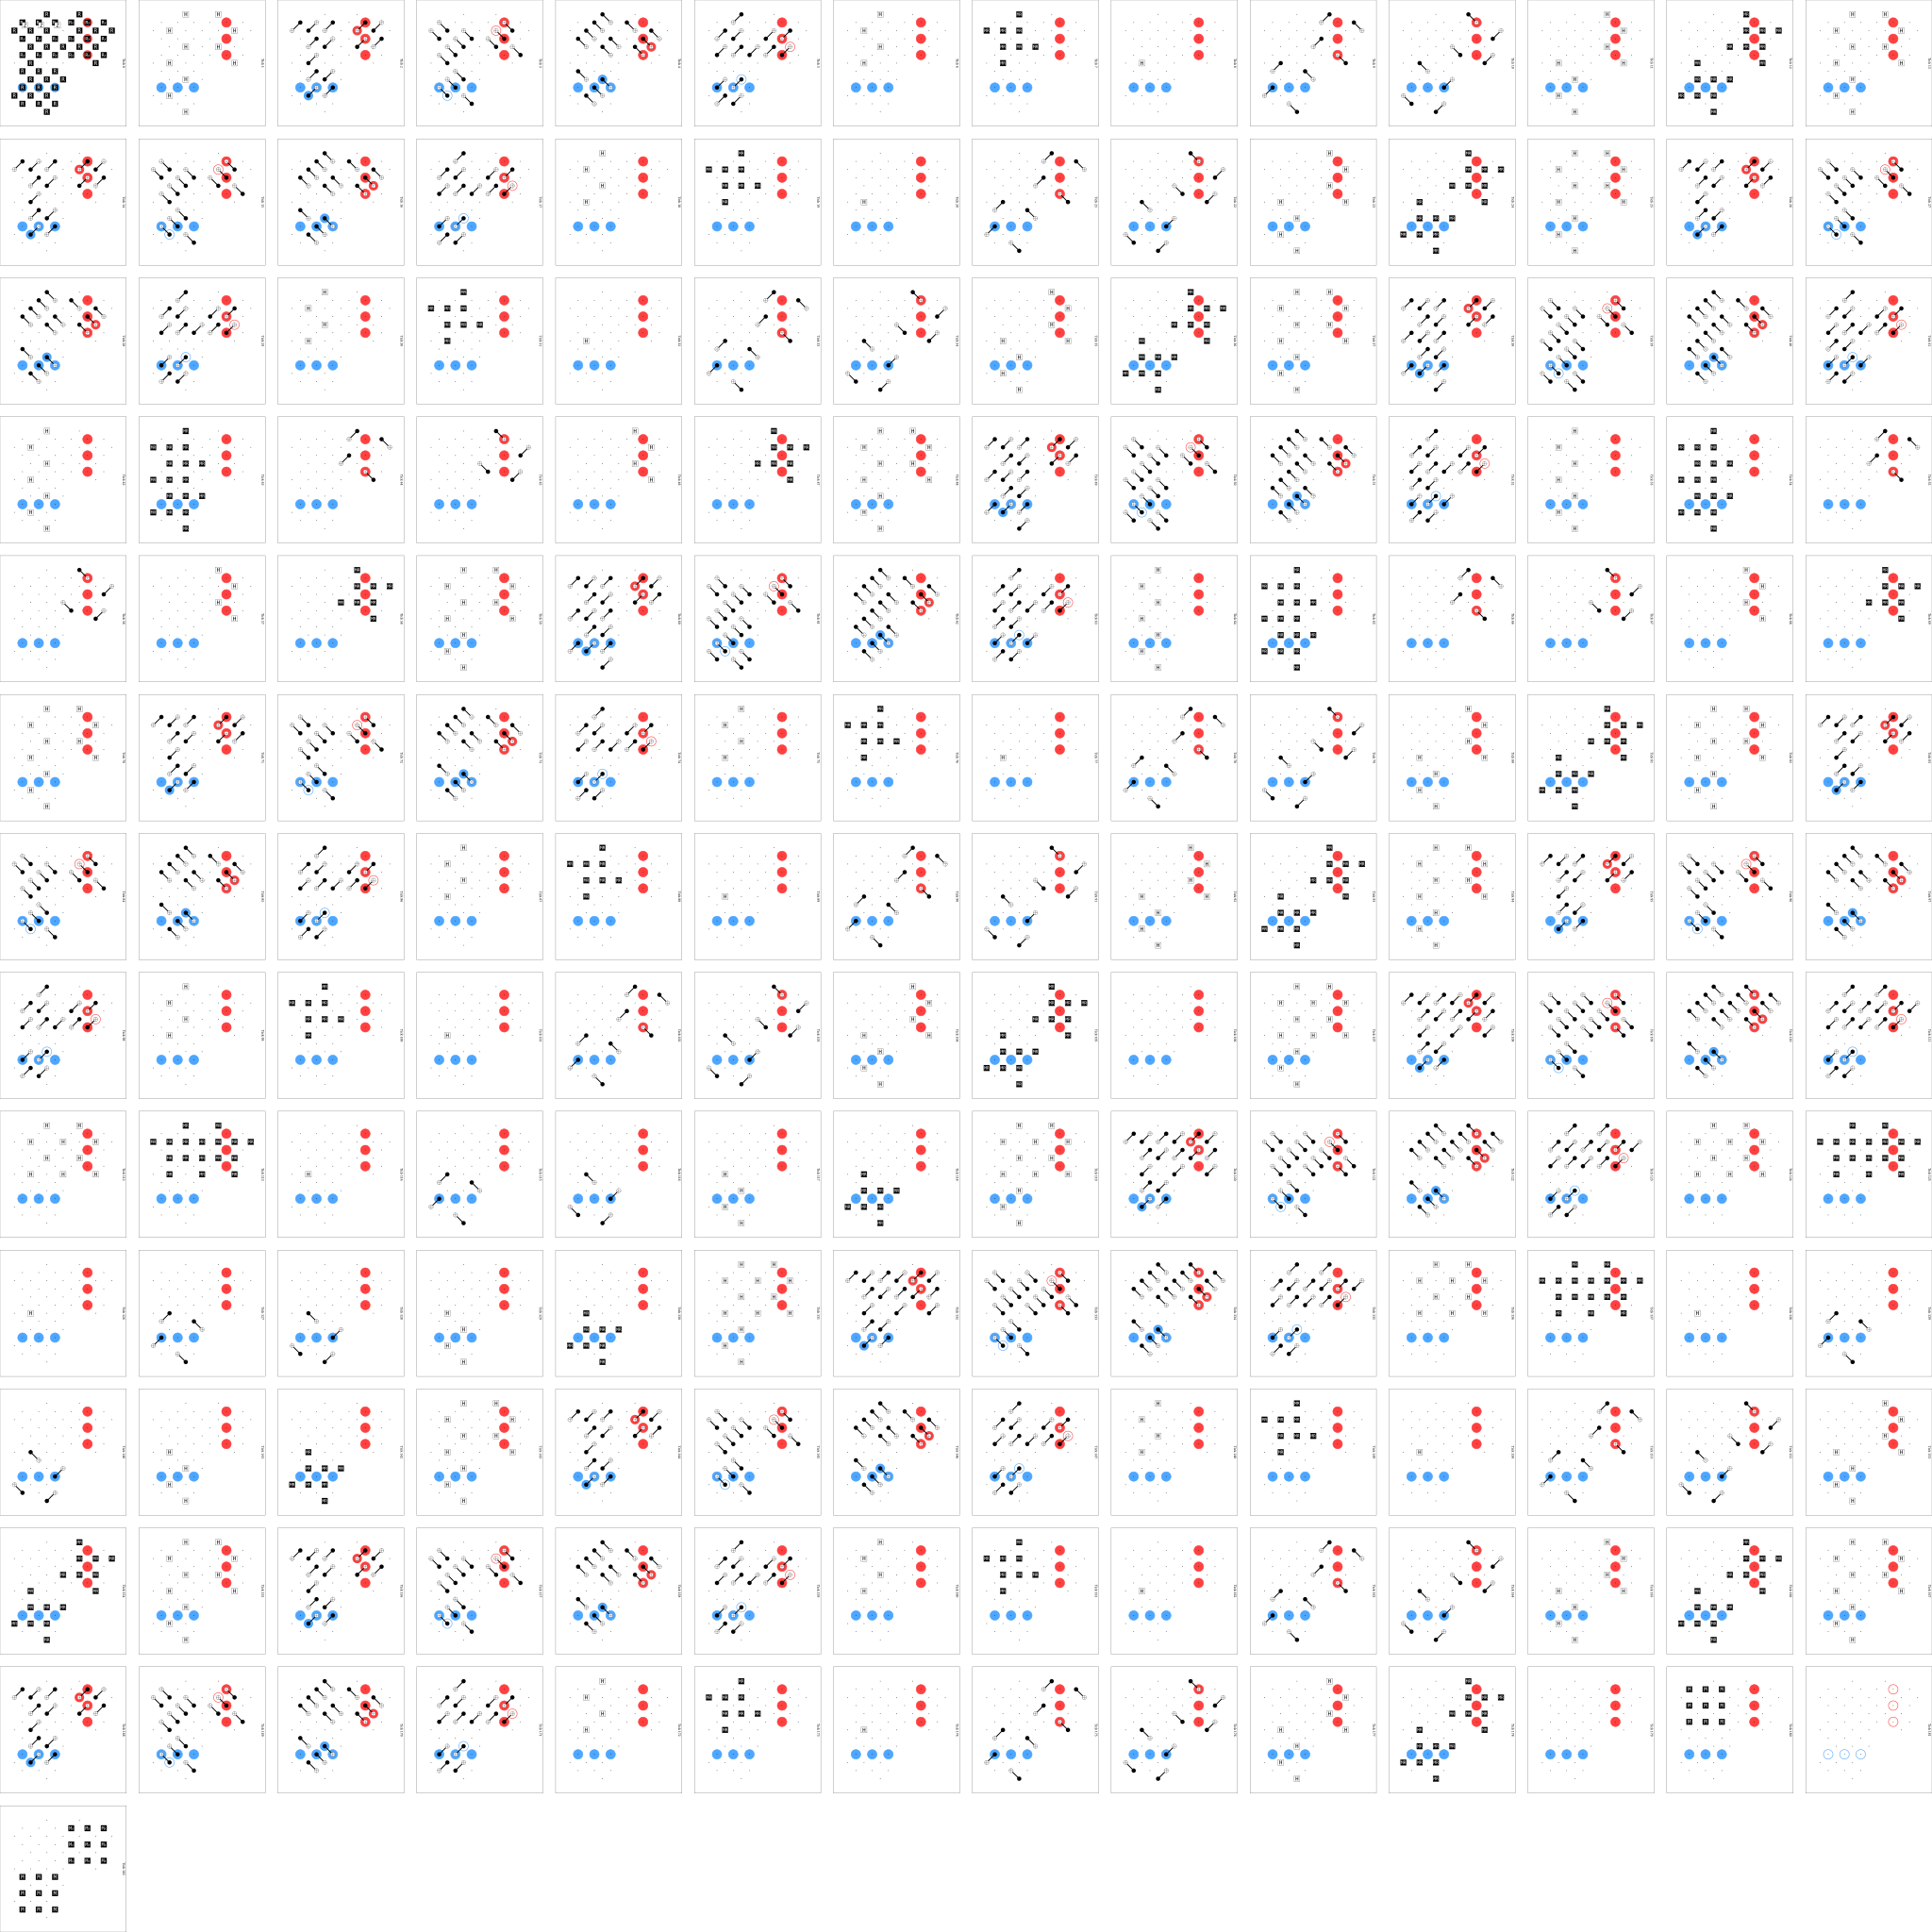

In [225]:
surgery_circuit(distance = 3, target_state_init = "X-", control_state_init= "Z0").diagram('detslice-with-ops-svg', filter_coords=['L0', 'L1',])

In [86]:
'''
This is a test function in order to check whether the surface code memory can acutally be meassured
-> Looking at the refrence observables stim saves
'''

def logical_x_mean_value(circuit : stim.Circuit, shot : int, observable : int):

    #Defining Circuit and DEM
    det_sampler = circuit.compile_detector_sampler()

    #Check if any logical Observable was flipped
    flip = det_sampler.sample(shots = shot, prepend_observables= True)[:, observable]

    print(flip)

    #Check normal logical vlaue of observable
    det_ref, obs_ref = circuit.reference_detector_and_observable_signs()
    print(obs_ref)
    
    #Boolean of measurements
    sign_bits  = flip ^ obs_ref[observable]

    #Translating into +1/-1 Statements
    full_sum = []

    for elements in sign_bits:
        if elements == False:
            full_sum.append(1)
        elif elements == True:
            full_sum.append(-1)

    #Count the different results:
    count_off = 0
    count_on = 0

    for results in full_sum:
        if results == 1:
            count_off +=1
        elif results == -1:
            count_on +=1

    return(count_off / shot, count_on / shot)

In [112]:
test_circuit = surgery_circuit(3, target_state_init="Z0", control_state_init="Z1")

'''
Cheat-Sheet:
0 -> Observable Ancilla
1 -> Observable Control -> 0
2 -> Observable Target  -> 1
'''

x_values = ["Z0", "Z1"]
y_values = logical_x_mean_value(test_circuit, 10000, 0)

# Create the plot
plt.figure(figsize=(6, 4))
plt.bar(x_values, y_values)

# Format y-axis as percentages
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Labels and title
plt.xlabel('Logical State')
plt.ylabel('Percentage')
plt.title('State Distribution of a CX with init. state of C=1, T=0')

plt.tight_layout()
plt.show()

'''
THIS IS NOT WORKING BECAUSE:
-> We only have Observable includes with no actual measurement refrences
-> Therefore we need to add the same observables at the end after measurement with the same index (I guess?)
'''

ValueError: While running backwards through the circuit, during reverse-execution of the instruction
    RX 3 4 5 14 15 16 27 28 29
the following detecting region vs dissipation anticommutations occurred
    L0 vs stim.target_z(29)
Therefore invalid detectors/observables are present in the circuit.


In [94]:
task_noisy = [sinter.Task(
    circuit = surgery_circuit(
        distance = d,
        control_state_init = c_state,
        target_state_init = t_state,
        noise_depol_data_init = 0.0,
        noise_measure_flip = noise
    ),
    json_metadata={'p': noise, 'distance' : d, 'state_control' : c_state, 'state_target' : t_state}
    ) 
    for noise in [0.010, 0.015, 0.1, 0.125, 0.2, 0.3, 0.35, 0.4, 0.45]
    for d in [3,5,7]
    for c_state in {"Z1"}
    for t_state in {"Z0"}
    ]

stats_noisy : list[sinter.TaskStats] = sinter.collect(
    num_workers = os.cpu_count(),
    tasks=task_noisy,
    decoders=['pymatching'],
    max_shots=100_000_0,
    max_errors=1000,
    print_progress=True
)

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "c:\Users\f.spreemann\Documents\PYM STIM ENVIROMENT\.venv\Lib\site-packages\IPython\core\interactiveshell.py", line 3549, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\f.spreemann\AppData\Local\Temp\ipykernel_37428\2963791358.py", line 1, in <module>
    task_noisy = [sinter.Task(
                 ^^^^^^^^^^^^^
  File "C:\Users\f.spreemann\AppData\Local\Temp\ipykernel_37428\2963791358.py", line 2, in <listcomp>
    circuit = surgery_circuit(
              ^^^^^^^^^^^^^^^^
  File "<string>", line 34, in surgery_circuit
  File "<string>", line None, in split
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\f.spreemann\Documents\PYM STIM ENVIROMENT\.venv\Lib\site-packages\IPython\core\interactiveshell.py", line 2173, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^

In [11]:
#Dumping Stats with pickle:
with open("lattice_surgery_measurement_noise.pkl", "wb") as file:
    pickle.dump(stats_noisy, file)

In [ ]:
#Loading Stats with pickle
with open("lattice_surgery_measurement_noise.pkl", "rb") as file:
    complete_stats = pickle.load(file)

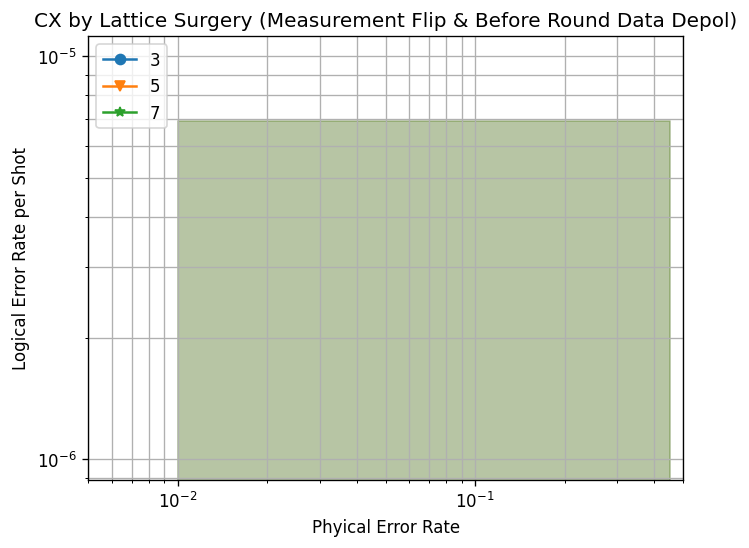

In [15]:
fig, ax = plt.subplots(1,1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats_noisy,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['distance']
)
ax.loglog()
ax.set_xlim(5e-3, 0.5)
ax.set_title("CX by Lattice Surgery (Measurement Flip & Before Round Data Depol)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger